In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [4]:
pip install ucimlrepo

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets

# metadata
print(covertype.metadata)

# variable information
print(covertype.variables)


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [6]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0


In [7]:
y.head()

,Cover_Type
0,5
1,5
2,2
3,2
4,5


In [8]:
y = covertype.data.targets.copy()
y['Cover_Type'] = y['Cover_Type'] - 1
y.head()

,Cover_Type
0,4
1,4
2,1
3,1
4,4


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


class_counts = y['Cover_Type'].value_counts().sort_index()
print("Class Counts:\n", class_counts)


most_frequent_class = class_counts.idxmax()
least_frequent_class = class_counts.idxmin()

most_frequent_count = class_counts.max()
least_frequent_count = class_counts.min()

imbalance_ratio = most_frequent_count / least_frequent_count

print(f"\nMost frequent class: {most_frequent_class} (count: {most_frequent_count})")
print(f"Least frequent class: {least_frequent_class} (count: {least_frequent_count})")
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

Class Counts:
 Cover_Type
0    211840
1    283301
2     35754
3      2747
4      9493
5     17367
6     20510
Name: count, dtype: int64

Most frequent class: 1 (count: 283301)
Least frequent class: 3 (count: 2747)
Imbalance Ratio (Max/Min): 103.13


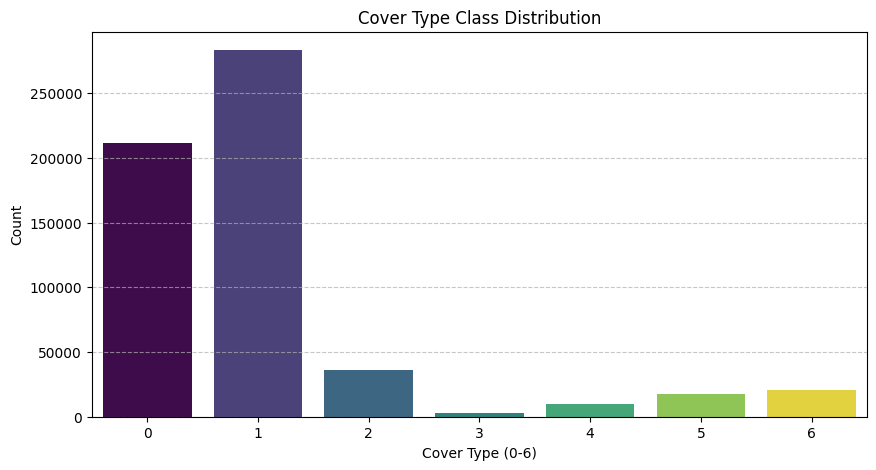

In [10]:

plt.figure(figsize=(10, 5))
sns.countplot(data=y, x='Cover_Type', palette='viridis', hue='Cover_Type', legend=False)
plt.title('Cover Type Class Distribution')
plt.xlabel('Cover Type (0-6)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
import pandas as pd


print(f"Features shape: {X.shape} (54 features)")


y_one_hot = pd.get_dummies(y['Cover_Type'], dtype=int)

print(f"One-hot target shape: {y_one_hot.shape} (7 classes)")
display(y_one_hot.head())

Features shape: (581012, 54) (54 features)
One-hot target shape: (581012, 7) (7 classes)


,0,1,2,3,4,5,6
0,0,0,0,0,1,0,0
1,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0
4,0,0,0,0,1,0,0


In [12]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_one_hot,
    test_size=0.2,
    random_state=42,
    stratify=y['Cover_Type']
)


y_temp_labels = y_temp.idxmax(axis=1)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_labels
)


print(f"Training set shape:   {X_train.shape} ({(X_train.shape[0]/X.shape[0])*100:.1f}%)")
print(f"Validation set shape: {X_val.shape} ({(X_val.shape[0]/X.shape[0])*100:.1f}%)")
print(f"Testing set shape:    {X_test.shape} ({(X_test.shape[0]/X.shape[0])*100:.1f}%)")

Training set shape:   (464809, 54) (80.0%)
Validation set shape: (58101, 54) (10.0%)
Testing set shape:    (58102, 54) (10.0%)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train features mean (first 5):", X_train_scaled.mean(axis=0)[:5])
print("Train features std (first 5): ", X_train_scaled.std(axis=0)[:5])

Train features mean (first 5): [-4.14623009e-16  4.00207587e-17 -7.94682636e-17  5.49253575e-17
  3.65353756e-17]
Train features std (first 5):  [1. 1. 1. 1. 1.]


In [14]:
import numpy as np

N = len(y_train)
K = y_train.shape[1]
nc = y_train.sum(axis=0).values

class_weights = N / (K * nc)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class counts in training set:", nc)
print("Calculated class weights:", class_weight_dict)

Class counts in training set: [169472 226640  28603   2198   7594  13894  16408]
Calculated class weights: {0: np.float64(0.39181272253992233), 1: np.float64(0.29298131712974634), 2: np.float64(2.3214797648598298), 3: np.float64(30.209866112049916), 4: np.float64(8.743914368486399), 5: np.float64(4.779133850171708), 6: np.float64(4.046884794873581)}


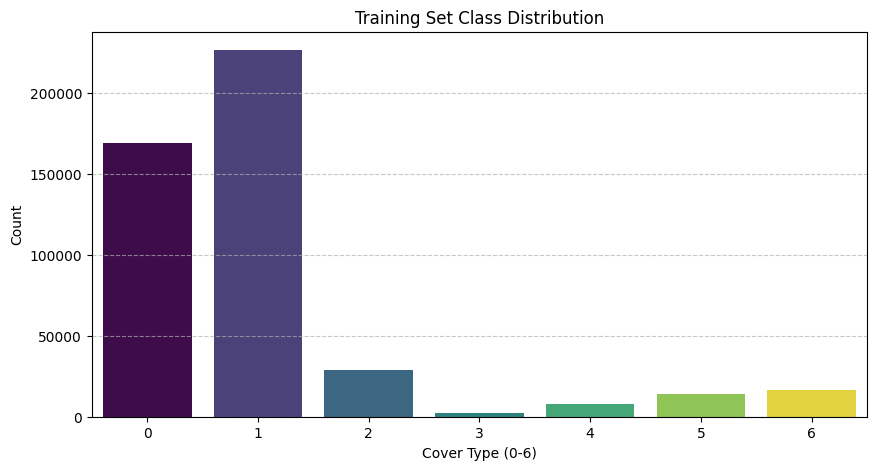

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

train_counts = y_train.sum(axis=0)

plt.figure(figsize=(10, 5))
sns.barplot(x=train_counts.index, y=train_counts.values, palette='viridis', hue=train_counts.index, legend=False)
plt.title('Training Set Class Distribution')
plt.xlabel('Cover Type (0-6)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
import numpy as np

class CustomNeuralNetwork:
    def __init__(self, layers=[54, 64, 32, 16, 7], class_weights=None):
        self.layers = layers
        self.parameters = {}
        self.class_weights = class_weights if class_weights is not None else np.ones(layers[-1])
        self.initialize_parameters()

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.layers)):
            # He (Kaiming) Initialization: Normal distribution scaled by sqrt(2/n_{l-1})
            scale = np.sqrt(2.0 / self.layers[l-1])
            self.parameters[f'W{l}'] = np.random.randn(self.layers[l], self.layers[l-1]) * scale
            self.parameters[f'b{l}'] = np.zeros((self.layers[l], 1))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return np.where(Z > 0, 1.0, 0.0)

    def softmax(self, Z):
        # Subtract max for numerical stability
        exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

    def forward_propagation(self, X):
        # X should be transposed to shape (features, batch_size)
        cache = {'A0': X}
        A = X

        for l in range(1, len(self.layers) - 1):
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']
            Z = np.dot(W, A) + b
            A = self.relu(Z)
            cache[f'Z{l}'] = Z
            cache[f'A{l}'] = A

        # Output layer with Softmax
        L = len(self.layers) - 1
        W_out = self.parameters[f'W{L}']
        b_out = self.parameters[f'b{L}']
        Z_out = np.dot(W_out, A) + b_out
        A_out = self.softmax(Z_out)
        cache[f'Z{L}'] = Z_out
        cache[f'A{L}'] = A_out

        return A_out, cache

    def compute_loss(self, A_out, Y):
        # Y should be of shape (classes, batch_size)
        m = Y.shape[1]
        epsilon = 1e-15
        clipped_A = np.clip(A_out, epsilon, 1 - epsilon)

        # Weighted Categorical Cross-Entropy loss calculation
        # shape of class_weights is (7, 1)
        weights = self.class_weights.reshape(-1, 1)
        loss = -np.sum(weights * Y * np.log(clipped_A)) / m
        return loss

    def backpropagation(self, Y, cache):
        # Y shape: (classes, batch_size)
        m = Y.shape[1]
        grads = {}
        L = len(self.layers) - 1

        A_out = cache[f'A{L}']
        A_prev = cache[f'A{L-1}']
        weights = self.class_weights.reshape(-1, 1)

        # Derivative of weighted loss w.r.t logits Z_L
        # dZ = (W_class * A_out - W_class * Y) + (Y * W_class) * sum_classes(Y * A_out)
        # For cross-entropy combined with softmax, incorporating the vector of class weights:
        dZ = weights * (A_out - Y)

        grads[f'dW{L}'] = np.dot(dZ, A_prev.T) / m
        grads[f'db{L}'] = np.sum(dZ, axis=1, keepdims=True) / m

        for l in range(L - 1, 0, -1):
            W_next = self.parameters[f'W{l+1}']
            Z_curr = cache[f'Z{l}']
            A_prev_curr = cache[f'A{l-1}']

            dA = np.dot(W_next.T, dZ)
            dZ = dA * self.relu_derivative(Z_curr)

            grads[f'dW{l}'] = np.dot(dZ, A_prev_curr.T) / m
            grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True) / m

        return grads

# Instantiate the network structure
nn = CustomNeuralNetwork(layers=[54, 64, 32, 16, 7], class_weights=class_weights)
print("Neural Network successfully initialized with He initialization & custom weighted loss structure.")

Neural Network successfully initialized with He initialization & custom weighted loss structure.


Starting Mini-batch SGD Training with Early Stopping...
Epoch 001 - Train Loss: 1.35605 - Val Loss: 1.16568
Epoch 005 - Train Loss: 0.91315 - Val Loss: 1.20649
Epoch 010 - Train Loss: 0.75937 - Val Loss: 0.76527
Epoch 015 - Train Loss: 0.67289 - Val Loss: 0.61737
Epoch 020 - Train Loss: 0.62425 - Val Loss: 0.56827
Epoch 025 - Train Loss: 0.59841 - Val Loss: 0.66632
Epoch 030 - Train Loss: 0.60743 - Val Loss: 0.61839
Epoch 035 - Train Loss: 0.57872 - Val Loss: 0.63012
Epoch 040 - Train Loss: 0.55481 - Val Loss: 0.56313
Epoch 045 - Train Loss: 0.54420 - Val Loss: 0.66147
Epoch 050 - Train Loss: 0.52930 - Val Loss: 0.58529
Epoch 055 - Train Loss: 0.51670 - Val Loss: 0.57311
Epoch 060 - Train Loss: 0.53130 - Val Loss: 0.48819
Epoch 065 - Train Loss: 0.51271 - Val Loss: 0.57116

Early stopping triggered at epoch 67. Reverting to best model parameters.


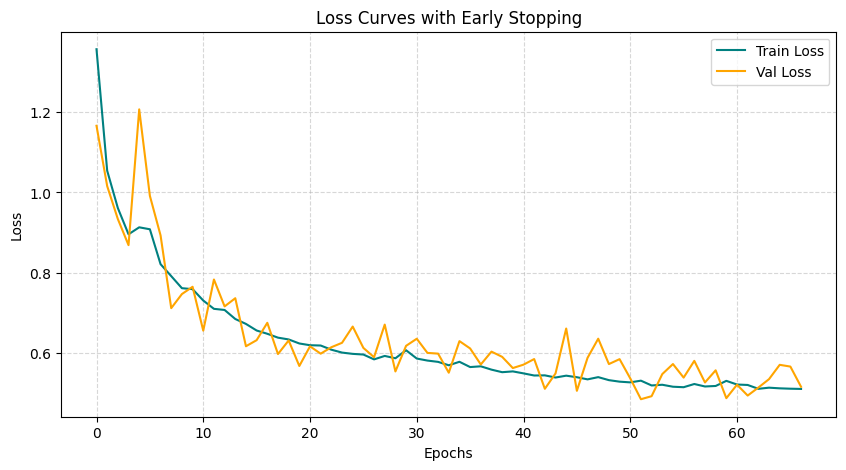

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import copy

def train_with_early_stopping(model, X_train, Y_train, X_val, Y_val, epochs=200, batch_size=128, learning_rate=0.01, patience=15):
    # Transpose input data for neural network [features, samples]
    X_tr = X_train.T
    Y_tr = Y_train.values.T
    X_v = X_val.T
    Y_v = Y_val.values.T

    m = X_tr.shape[1]
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_parameters = None
    epochs_no_improve = 0

    # Velocity parameters for momentum to assist SGD stability
    v = {f'dW{l}': np.zeros_like(model.parameters[f'W{l}']) for l in range(1, len(model.layers))}
    v.update({f'db{l}': np.zeros_like(model.parameters[f'b{l}']) for l in range(1, len(model.layers))})
    beta = 0.9

    print("Starting Mini-batch SGD Training with Early Stopping...")
    for epoch in range(1, epochs + 1):
        # Shuffle training set at the start of each epoch
        permutation = np.random.permutation(m)
        X_tr_shuffled = X_tr[:, permutation]
        Y_tr_shuffled = Y_tr[:, permutation]

        epoch_loss = 0
        num_batches = int(np.ceil(m / batch_size))

        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, m)
            if start_idx == end_idx:
                continue

            X_batch = X_tr_shuffled[:, start_idx:end_idx]
            Y_batch = Y_tr_shuffled[:, start_idx:end_idx]

            # Forward Propagation
            A_out, cache = model.forward_propagation(X_batch)

            # Compute batch loss
            loss = model.compute_loss(A_out, Y_batch)
            epoch_loss += loss * (end_idx - start_idx)

            # Backpropagation
            grads = model.backpropagation(Y_batch, cache)

            # Parameter update via SGD with Momentum
            for l in range(1, len(model.layers)):
                v[f'dW{l}'] = beta * v[f'dW{l}'] + (1 - beta) * grads[f'dW{l}']
                v[f'db{l}'] = beta * v[f'db{l}'] + (1 - beta) * grads[f'db{l}']

                model.parameters[f'W{l}'] -= learning_rate * v[f'dW{l}']
                model.parameters[f'b{l}'] -= learning_rate * v[f'db{l}']

        epoch_loss /= m
        train_losses.append(epoch_loss)

        # Validation Evaluation
        A_val_out, _ = model.forward_propagation(X_v)
        val_loss = model.compute_loss(A_val_out, Y_v)
        val_losses.append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} - Train Loss: {epoch_loss:.5f} - Val Loss: {val_loss:.5f}")

        # Early Stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_parameters = copy.deepcopy(model.parameters)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}. Reverting to best model parameters.")
                model.parameters = best_parameters
                break

    return train_losses, val_losses

# Instantiate a clean model with calculated class weights
model = CustomNeuralNetwork(layers=[54, 64, 32, 16, 7], class_weights=class_weights)

# Train model
train_losses, val_losses = train_with_early_stopping(
    model=model,
    X_train=X_train_scaled,
    Y_train=y_train,
    X_val=X_val_scaled,
    Y_val=y_val,
    epochs=100,  # Max epochs set to 100 for this demonstration
    batch_size=128,
    learning_rate=0.01,
    patience=15
)

# Plot the learning curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='teal')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss Curves with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [20]:
# Predict class probabilities on the test set using forward propagation
A_test_prob, _ = model.forward_propagation(X_test_scaled.T)

# Convert probabilities to class labels using argmax (along the classes dimension)
y_pred_labels = np.argmax(A_test_prob, axis=0)
y_true_labels = np.argmax(y_test.values, axis=1)

# Compute evaluation metrics
accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision, recall, f1, support = precision_recall_fscore_support(y_true_labels, y_pred_labels, average=None)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true_labels, y_pred_labels, average='macro')

print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"Macro Precision:   {macro_precision:.4f}")
print(f"Macro Recall:      {macro_recall:.4f}")
print(f"Macro F1-Score:    {macro_f1:.4f}\n")

print("Per-Class Performance Metrics (Forest Cover Type 0 to 6):")
print(f"{'Class':<8} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Support':<10}")
print("-" * 58)
for i in range(7):
    print(f"{i:<8} | {precision[i]:<10.4f} | {recall[i]:<10.4f} | {f1[i]:<10.4f} | {support[i]:<10}")

Test Set Accuracy: 0.7858
Macro Precision:   0.7850
Macro Recall:      0.8039
Macro F1-Score:    0.7937

Per-Class Performance Metrics (Forest Cover Type 0 to 6):
Class    | Precision  | Recall     | F1-Score   | Support   
----------------------------------------------------------
0        | 0.7571     | 0.7445     | 0.7508     | 21184     
1        | 0.8043     | 0.8023     | 0.8033     | 28331     
2        | 0.8120     | 0.8540     | 0.8325     | 3576      
3        | 0.8352     | 0.7956     | 0.8150     | 274       
4        | 0.7147     | 0.8051     | 0.7572     | 949       
5        | 0.7150     | 0.6978     | 0.7063     | 1737      
6        | 0.8569     | 0.9283     | 0.8912     | 2051      


7x7 Confusion Matrix:
[[15772  5067    13     0    39     4   289]
 [ 4907 22730   257     0   254   154    29]
 [    2   179  3054    23    11   307     0]
 [    0     0    43   218     0    13     0]
 [    5   149    26     0   764     5     0]
 [    1   135   368    20     1  1212     0]
 [  145     2     0     0     0     0  1904]]


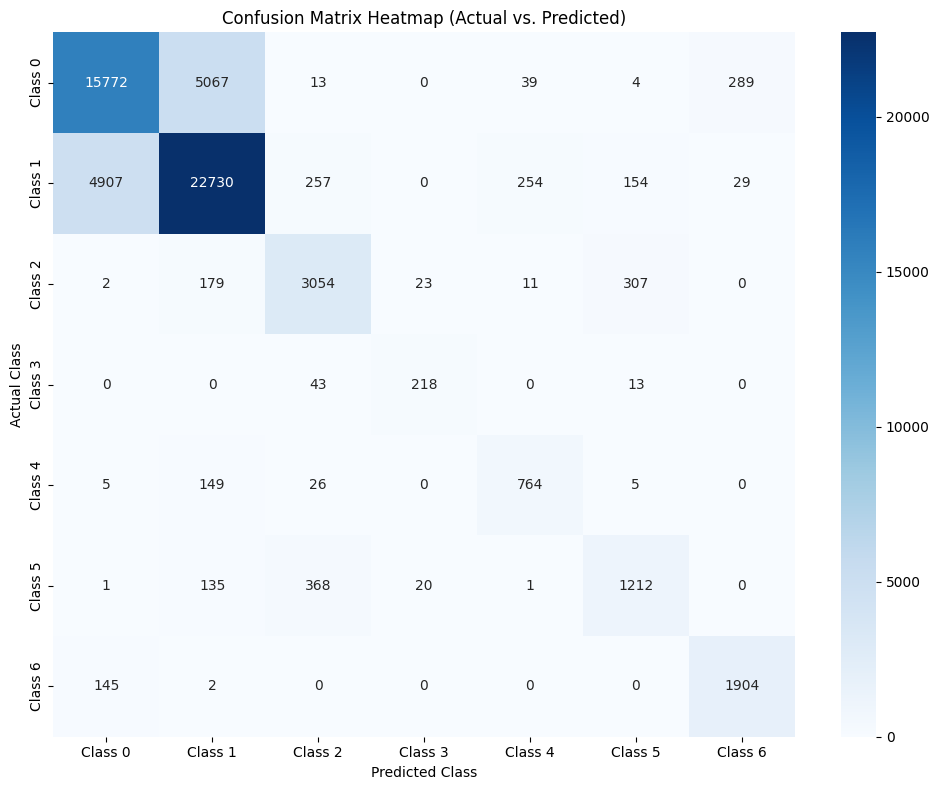

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute 7x7 Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print("7x7 Confusion Matrix:")
print(cm)

# Create Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'Class {i}' for i in range(7)],
    yticklabels=[f'Class {i}' for i in range(7)]
)
plt.title('Confusion Matrix Heatmap (Actual vs. Predicted)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

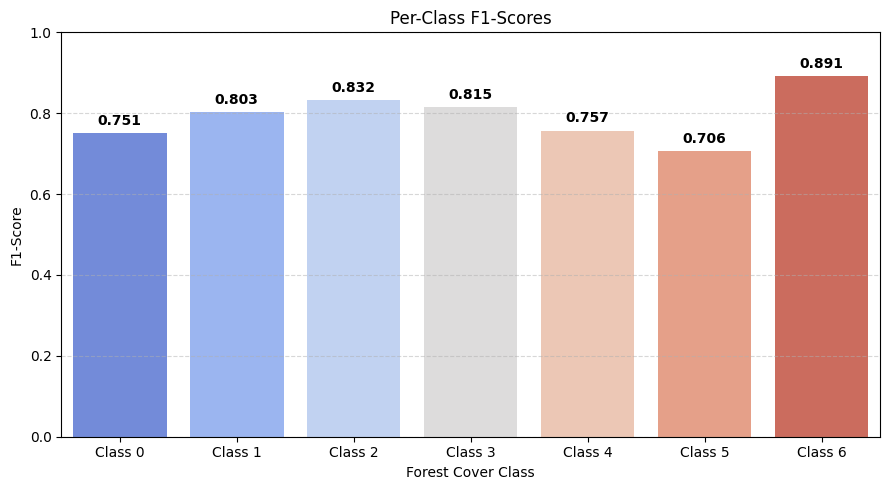

In [22]:
# Plot per-class F1 scores
classes = [f'Class {i}' for i in range(7)]

plt.figure(figsize=(9, 5))
sns.barplot(x=classes, y=f1, palette='coolwarm', hue=classes, legend=False)
plt.title('Per-Class F1-Scores')
plt.xlabel('Forest Cover Class')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
for i, score in enumerate(f1):
    plt.text(i, score + 0.02, f'{score:.3f}', ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

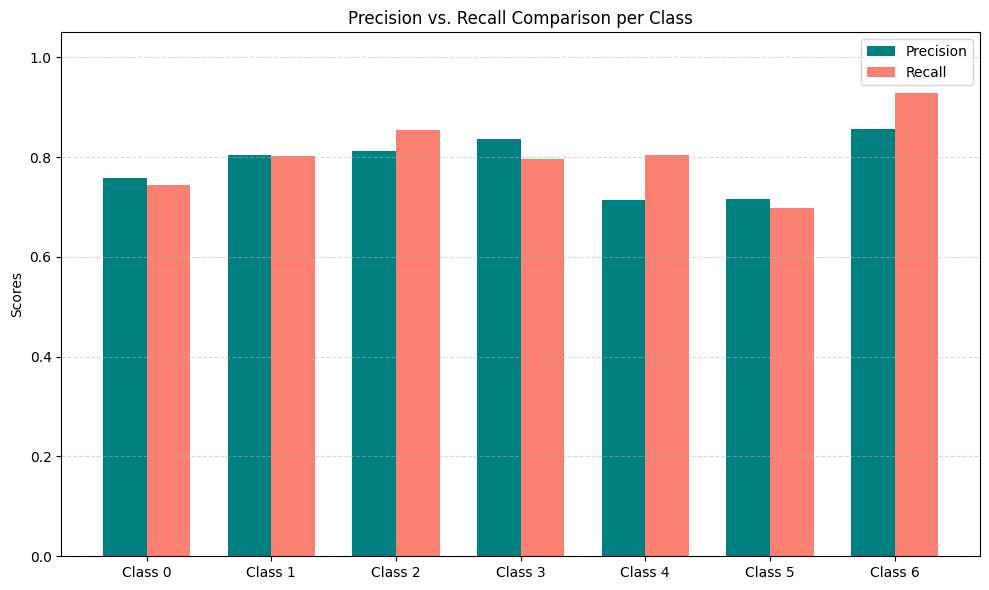

In [23]:
# Analyze precision vs recall trade-offs for each class
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, precision, width, label='Precision', color='teal')
ax.bar(x + width/2, recall, width, label='Recall', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Precision vs. Recall Comparison per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

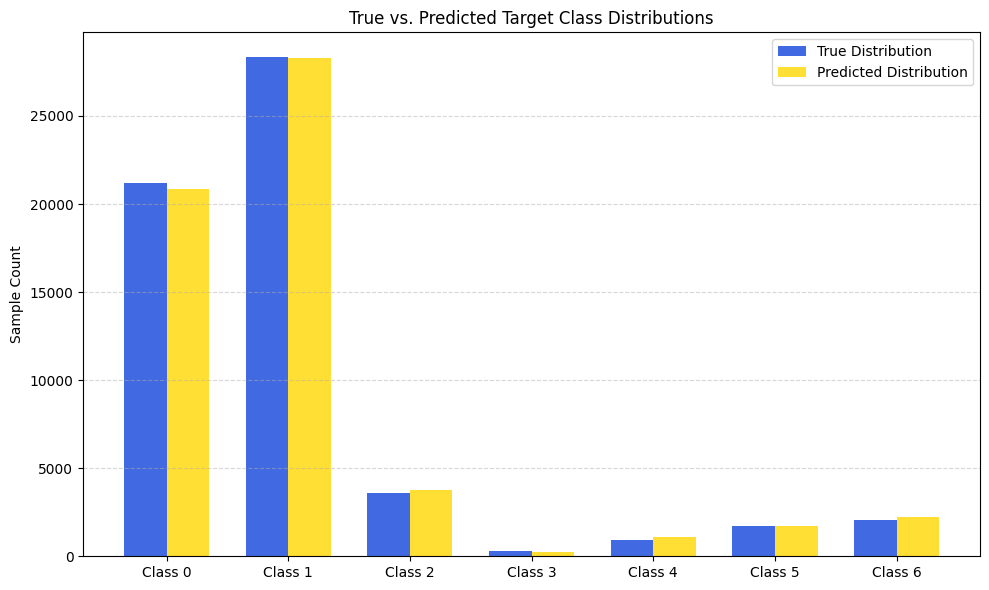

In [24]:
# Compare true vs predicted class distributions
unique_pred, counts_pred = np.unique(y_pred_labels, return_counts=True)
unique_true, counts_true = np.unique(y_true_labels, return_counts=True)

# Align indices
pred_distribution = np.zeros(7)
true_distribution = np.zeros(7)

pred_distribution[unique_pred] = counts_pred
true_distribution[unique_true] = counts_true

x = np.arange(7)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, true_distribution, width, label='True Distribution', color='royalblue')
ax.bar(x + width/2, pred_distribution, width, label='Predicted Distribution', color='gold', alpha=0.8)

ax.set_ylabel('Sample Count')
ax.set_title('True vs. Predicted Target Class Distributions')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()